Juan Basante

Michael Salazar

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat


Implementación de funciones

In [2]:
def calculo_rms(signal):
    senal=np.array(signal)
    RMS=np.sqrt(np.mean(senal**2))
    return RMS



Análisis estadístico

In [3]:
data= loadmat('signals.mat')
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


Vector del tiempo 


In [8]:
fs=int(data['Fs'].flatten()[0])
ecg_raw = data ['ECG_asRecording'].flatten()
ecg_filt =data['ECG_filtered'].flatten()

#vector de tiempo
N=len(ecg_raw)
t=np.arange(N)/fs
duracion=N/fs
print(f"numero de muestras: {N}")
print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Duracion de la señal: {duracion} segundos") 




numero de muestras: 30720
Frecuencia de muestreo: 1024 Hz
Duracion de la señal: 30.0 segundos


Graficar la senal sin filtrar y filtrada

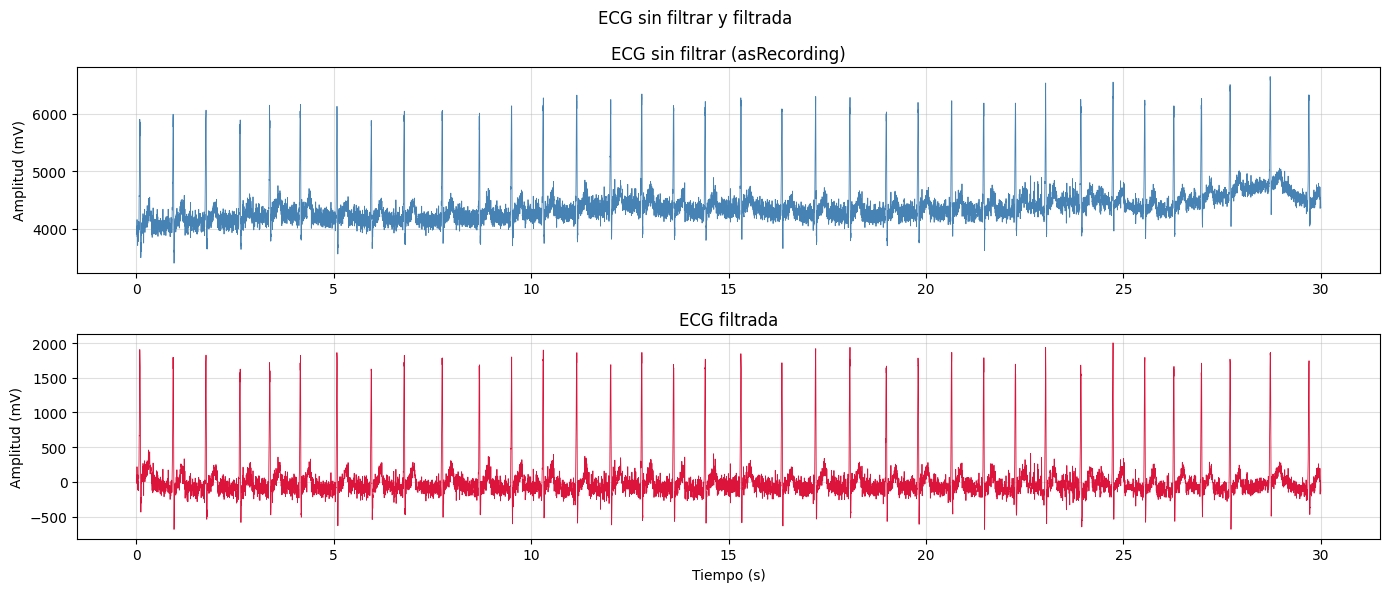

In [15]:
fig,axes=plt.subplots(2,1,figsize=(14,6))
fig.suptitle('ECG sin filtrar y filtrada')

axes[0].plot(t, ecg_raw, color='steelblue', linewidth=0.6)
axes[0].set_title('ECG sin filtrar (asRecording)')
axes[0].set_ylabel('Amplitud (mV)')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t, ecg_filt, color='crimson', linewidth=0.6)
axes[1].set_title('ECG filtrada')
axes[1].set_ylabel('Amplitud (mV)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Al comparar la senal ECG sin filtrar con la senal filtrada, se puede indentificar diferencias.

En la senal sin filtrar se observa la presencia de un offset considerable, que eleva la linea base de la senal aproximadamente entre 4000 mV, lo cual dificulta la visualizacion e interpretacion de los componenetes del ECG. Tambien , podemos observar una leve deriva de la linea base lo que afecta vizualizar los complejos que deben ser negativos.

En la senal filtrada, la linea base se encuentra centrada en 0 mV, lo que permite identificar con claridad los complejos negativos gracias a que ahora no existe un offset.

Respecto al comportamiento del filtro utilizado, puede ser un filtro pasa banda con dos frecuencias de corte, una frecuencia inferior para eliminar el offset y la deriva de la linea base y la frecuencia de corte superior elimna el ruido de alta frecuencia, 

*RMS para senal sin filtrar*

 ECG SIN FILTRAR — Un ciclo cardíaco 
  Promedio       : 4131.1363 mV
  Valor RMS      : 4142.4550 mV
  Varianza       : 93646.2221 mV^2
  Desv. estándar : 306.0167 mV


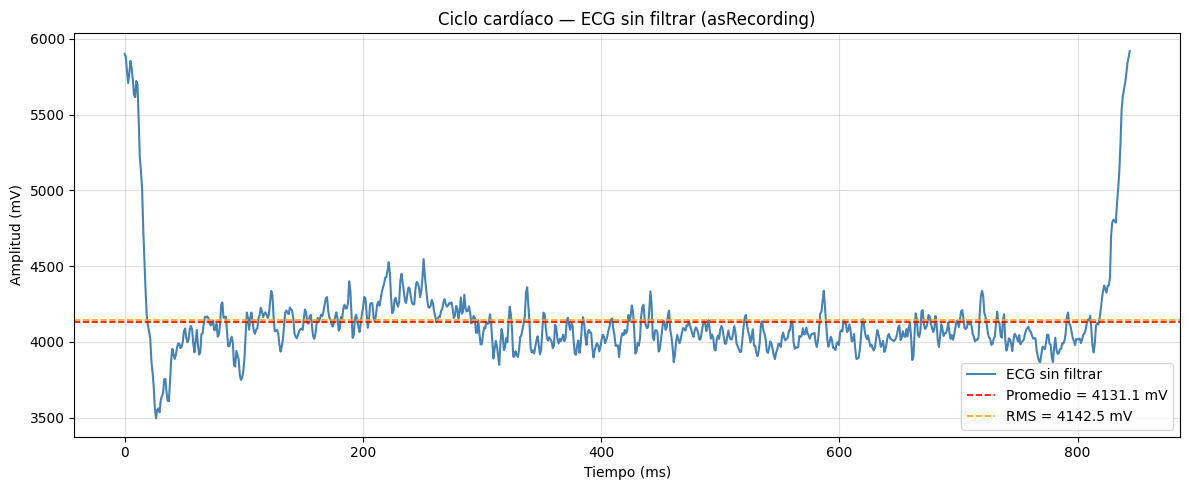

In [14]:
from scipy.signal import find_peaks
peaks_raw, _ = find_peaks(ecg_raw, height=5500, distance=int(0.6*fs))
ciclo_raw = ecg_raw[peaks_raw[0] : peaks_raw[1]]
t_ciclo   = np.arange(len(ciclo_raw)) / fs * 1000 
promedio = np.mean(ciclo_raw)
rms      = calculo_rms(ciclo_raw)
varianza = np.var(ciclo_raw)
std      = np.std(ciclo_raw)
print(" ECG SIN FILTRAR — Un ciclo cardíaco ")
print(f"  Promedio       : {promedio:.4f} mV")
print(f"  Valor RMS      : {rms:.4f} mV")
print(f"  Varianza       : {varianza:.4f} mV^2")
print(f"  Desv. estándar : {std:.4f} mV")

plt.figure(figsize=(12, 5))
plt.plot(t_ciclo, ciclo_raw, color='steelblue', linewidth=1.5, label='ECG sin filtrar')
plt.axhline(promedio, color='red',    linestyle='--', linewidth=1.2, label=f'Promedio = {promedio:.1f} mV')
plt.axhline(rms,      color='orange', linestyle='--', linewidth=1.2, label=f'RMS = {rms:.1f} mV')
plt.title('Ciclo cardíaco — ECG sin filtrar (asRecording)')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud (mV)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Al analizar estos resultados, se observa que el promedio de 4131.14 mV es un valor elevado que no representa la actividad eléctrica real del corazón, sino que está completamente dominado por el offset DC presente en la señal sin procesar. Este offset corresponde a un componente de corriente continua introducido por la interfaz electrodo-piel y por los circuitos de adquisición.


El valor RMS de 4142.46 mV es muy similar al promedio, lo que confirma que la energía de la señal está dominada por dicho offset DC y no por la actividad cardíaca en sí. En condiciones ideales, el RMS debería ser mayor que el promedio solo cuando existe una componente alterna significativa; en este caso, la diferencia entre ambos es mínima (≈11 mV), evidenciando que la variación real de la señal es pequeña en comparación con el nivel DC.


La varianza de 93646.22 mV^2 y la desviación estándar de 306.02 mV reflejan la dispersión total de la señal alrededor de su media. Esta dispersión incluye tanto la amplitud real de los complejos QRS como el ruido de alta frecuencia superpuesto, por lo que no es un indicador puro de la actividad cardíaca. Sin embargo, es notable que aun con el pico R visible en la gráfica (~5900 mV), la desviación estándar sea relativamente pequeña comparada con el promedio, lo que indica que el pico R ocupa una fracción muy pequeña del ciclo y la mayor parte del tiempo la señal permanece cerca del nivel DC.


En conclusión, las métricas estadísticas de la señal sin filtrar están fuertemente sesgadas por el offset DC, lo que limita su utilidad clínica y justifica la necesidad del proceso de filtrado.

*RMS para senal filtrada*

 ECG FILTRADA — Un ciclo cardíaco 
  Promedio       : 74.0100 mV
  Valor RMS      : 319.6276 mV
  Varianza       : 96684.3149 mV^2
  Desv. estándar : 310.9410 mV


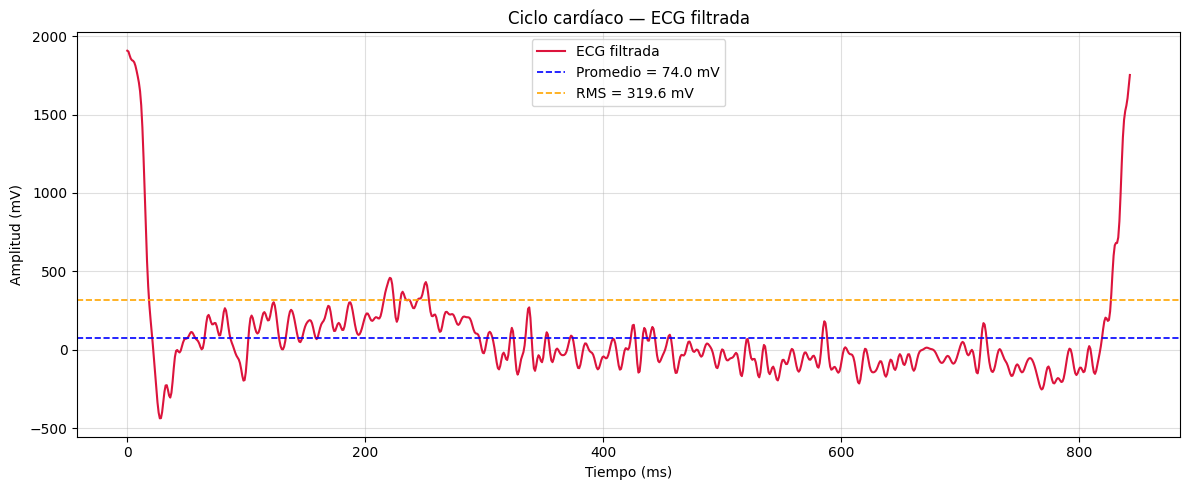

In [ ]:

peaks_filt, _ = find_peaks(ecg_filt, height=1000, distance=int(0.6*fs))
ciclo_filt = ecg_filt[peaks_filt[0] : peaks_filt[1]]
t_ciclo_f  = np.arange(len(ciclo_filt)) / fs * 1000  # milisegundos

promedio_f = np.mean(ciclo_filt)
rms_f      = calculo_rms(ciclo_filt)
varianza_f = np.var(ciclo_filt)
std_f      = np.std(ciclo_filt)

print(" ECG FILTRADA — Un ciclo cardíaco ")
print(f"  Promedio       : {promedio_f:.4f} mV")
print(f"  Valor RMS      : {rms_f:.4f} mV")
print(f"  Varianza       : {varianza_f:.4f} mV^2")
print(f"  Desv. estándar : {std_f:.4f} mV")

plt.figure(figsize=(12, 5))
plt.plot(t_ciclo_f, ciclo_filt, color='crimson', linewidth=1.5, label='ECG filtrada')
plt.axhline(promedio_f, color='blue',   linestyle='--', linewidth=1.2, label=f'Promedio = {promedio_f:.1f} mV')
plt.axhline(rms_f,      color='orange', linestyle='--', linewidth=1.2, label=f'RMS = {rms_f:.1f} mV')
plt.title('Ciclo cardíaco — ECG filtrada')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud (mV)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Análisis del promedio: El promedio descendió drásticamente de 4131.14 mV a 74.01 mV, una reducción del 98 %. Este resultado confirma que el filtro eliminó eficazmente el offset DC que dominaba la señal original.

Análisis del RMS: La reducción del RMS de 4142.46 mV a 319.63 mV es el resultado más revelador. En la señal sin filtrar, el RMS era prácticamente igual al promedio, lo que indicaba que la energía de la señal estaba dominada por el DC. En la señal filtrada, en cambio, el RMS (319.63 mV) es significativamente mayor que el promedio (74.01 mV)

Análisis de varianza y desviación estándar: Este es el resultado más interesante: la varianza y la desviación estándar son prácticamente iguales en ambas señales (93646 vs 96684 mV^2 y 306 vs 310 mV respectivamente). Esto tiene una explicación  directa  la varianza mide la dispersión alrededor de la media, por lo que es independiente del offset DC. El filtro no alteró la variabilidad intrínseca de la señal, solo desplazó su nivel medio. Este resultado valida que el filtrado no distorsionó ni perdió información de la actividad cardíaca real.

Conclusión comparativa: El proceso de filtrado logró eliminar el componente DC que enmascaraba la señal, haciendo que el promedio y el RMS ahora sean métricas útiles y representativas de la actividad eléctrica cardíaca. La invarianza de la varianza y desviación estándar ante el filtrado confirma que el filtro preservó la información clínica relevante de la señal ECG sin alterar su contenido frecuencial de interés


In [16]:
print('--'*70)

--------------------------------------------------------------------------------------------------------------------------------------------


Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria

Picos R detectados: 36
  Ciclo     Promedio (mV)   Varianza (mV^2)
     1          74.0100      96684.3149  
     2          -1.4626     104790.4655  
     3         -10.4330      82451.2511  
     4         -20.9752      46839.0197  
     5          40.8711     114850.0201  
     6         -27.9437      58147.5895  
     7           0.4308      77707.2812  
     8          21.4079     100268.1815  
     9         -10.1753      71784.9558  
    10           8.8121      68481.0598  
    11          -8.9062      76088.3849  
    12          13.2133      93862.6959  
    13          -4.2033      87951.5045  
    14         -14.9697      77022.1329  
    15          27.1083      89636.9356  

Promedio global de promedios : 5.7856 mV
Std de promedios             : 25.6227 mV
Promedio global de varianzas : 83104.3862 mV^2
Std de varianzas             : 17387.2649 mV^2


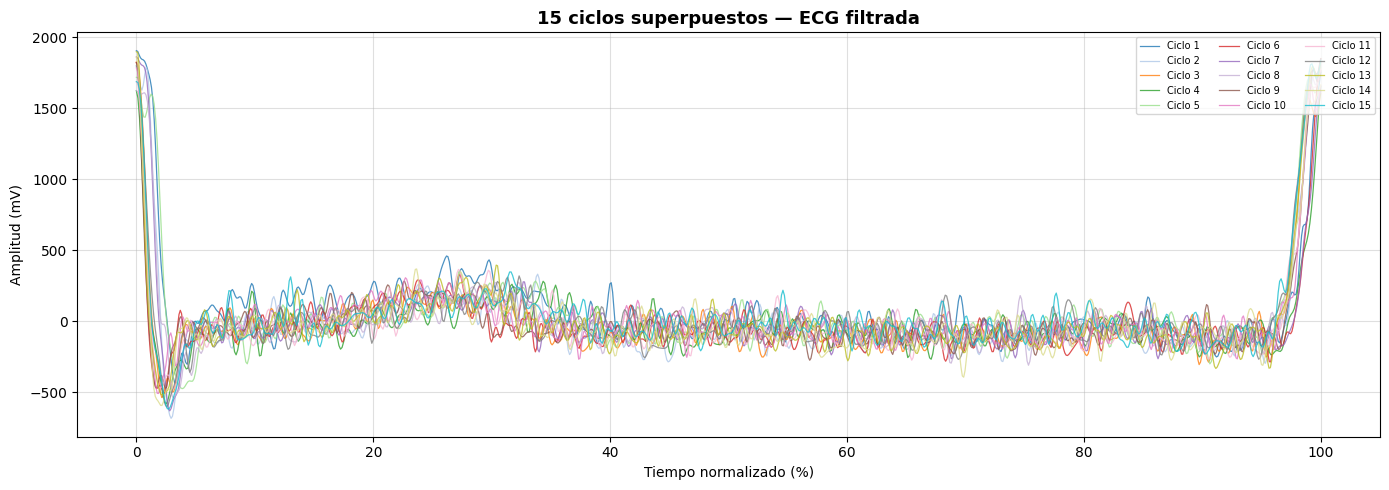

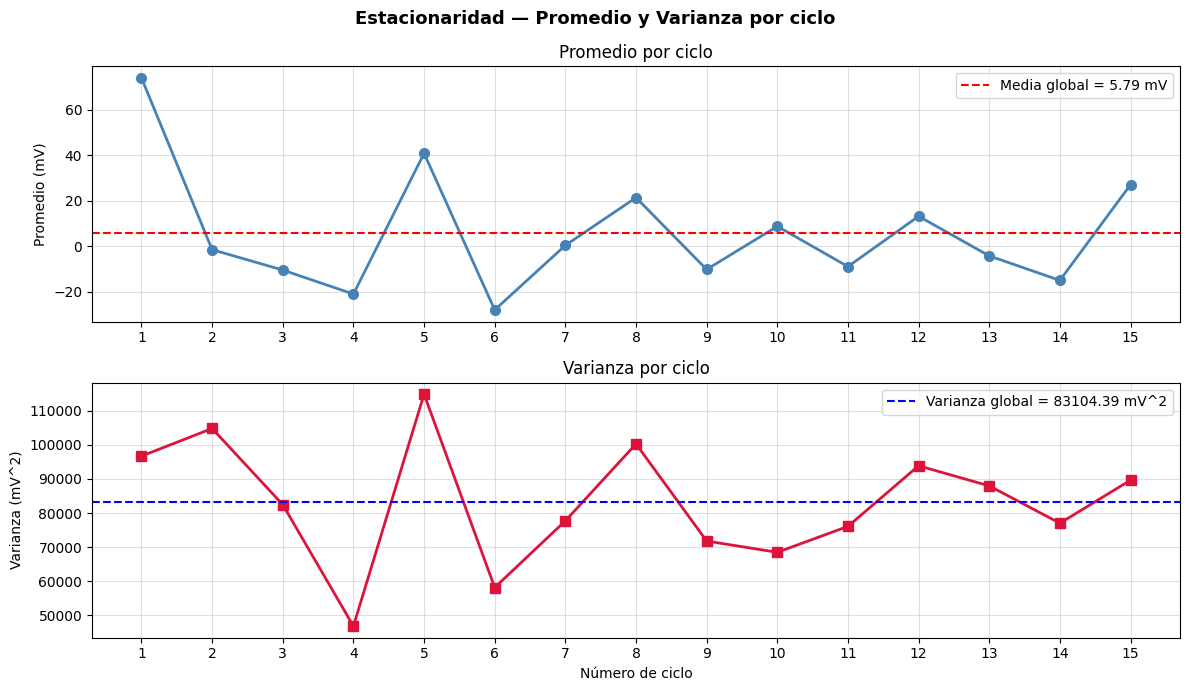

In [23]:

peaks_filt, _ = find_peaks(ecg_filt, height=1000, distance=int(0.6*fs))

print(f"Picos R detectados: {len(peaks_filt)}")  # Verificar que hay al menos 16

promedios = []
varianzas = []
ciclos    = []
tiempos   = []

for i in range(15):
    ciclo = ecg_filt[peaks_filt[i] : peaks_filt[i+1]]
    t_c   = np.arange(len(ciclo)) / fs * 1000
    
    ciclos.append(ciclo)
    tiempos.append(t_c)
    promedios.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

print("  Ciclo     Promedio (mV)   Varianza (mV^2)")

for i in range(15):
    print(f"    {i+1:2d}       {promedios[i]:10.4f}    {varianzas[i]:12.4f}  ")

print(f"\nPromedio global de promedios : {np.mean(promedios):.4f} mV")
print(f"Std de promedios             : {np.std(promedios):.4f} mV")
print(f"Promedio global de varianzas : {np.mean(varianzas):.4f} mV^2")
print(f"Std de varianzas             : {np.std(varianzas):.4f} mV^2")


plt.figure(figsize=(14, 5))
cmap = plt.cm.tab20
for i in range(15):

    t_norm = np.linspace(0, 100, len(ciclos[i]))
    plt.plot(t_norm, ciclos[i], color=cmap(i/15), linewidth=0.9, alpha=0.8, label=f'Ciclo {i+1}')

plt.title('15 ciclos superpuestos — ECG filtrada', fontsize=13, fontweight='bold')
plt.xlabel('Tiempo normalizado (%)')
plt.ylabel('Amplitud (mV)')
plt.legend(fontsize=7, ncol=3, loc='upper right')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fig.suptitle('Estacionaridad — Promedio y Varianza por ciclo', fontsize=13, fontweight='bold')

ciclo_nums = np.arange(1, 16)

axes[0].plot(ciclo_nums, promedios, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].axhline(np.mean(promedios), color='red', linestyle='--', linewidth=1.5, label=f'Media global = {np.mean(promedios):.2f} mV')
axes[0].set_title('Promedio por ciclo')
axes[0].set_ylabel('Promedio (mV)')
axes[0].set_xticks(ciclo_nums)
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(ciclo_nums, varianzas, 's-', color='crimson', linewidth=2, markersize=7)
axes[1].axhline(np.mean(varianzas), color='blue', linestyle='--', linewidth=1.5, label=f'Varianza global = {np.mean(varianzas):.2f} mV^2')
axes[1].set_title('Varianza por ciclo')
axes[1].set_ylabel('Varianza (mV^2)')
axes[1].set_xlabel('Número de ciclo')
axes[1].set_xticks(ciclo_nums)
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


Al graficar los 15 ciclos superpuestos, se puede observar que todos presentan una forma similar: un pico positivo pronunciado (onda R) al inicio, seguido de una deflexión negativa, y luego una región de menor amplitud que corresponde al segmento ST y la onda T. El hecho de que todos los ciclos tengan practicamente la misma forma indica que el corazón está latiendo de manera regular y consistente durante el registro.

**Análisis del promedio:**

Los promedios de cada ciclo oscilan entre -27.94 mV y 74.01 mV, girando alrededor de un valor global de 5.79 mV, es decir, muy cercano a cero. Esto indica que el filtrado funcionó correctamente, ya que la señal no tiene una tendencia a subir ni a bajar a lo largo del tiempo. El ciclo 1 tiene un promedio más alto que los demás (74 mV), lo cual puede deberse a condiciones del inicio del registro.

**Análisis de la varianza:**

La varianza fluctúa entre 46839 mV^2 y 114850 mV^2 según el ciclo. Esta variación entre latidos es normal y se debe a pequeñas diferencias naturales en la actividad eléctrica del corazón en cada contracción, así como al ruido residual presente en la señal.

**¿Es la señal estacionaria?**

La señal ECG no puede considerarse estrictamente estacionaria, dado que tanto el promedio como la varianza cambian de un ciclo a otro. Sin embargo, estas variaciones no siguen una tendencia clara ni crecen con el tiempo, sino que oscilan alrededor de valores relativamente constantes. Por esta razón, se puede decir que la señal es **aproximadamente estacionaria** en el corto plazo, lo cual es lo esperado para una señal fisiológica como el ECG en condiciones de reposo.


In [24]:
print('--'*70)


--------------------------------------------------------------------------------------------------------------------------------------------


*Prueba T*

In [37]:

from scipy import stats

pares   = [(0, 1), (6, 7)]
nombres = [("Ciclo 1", "Ciclo 2"), ("Ciclo 7", "Ciclo 8")]

for (i, j), (nom_i, nom_j) in zip(pares, nombres):
    
    c1 = np.array(ciclos[i], dtype=float)
    c2 = np.array(ciclos[j], dtype=float)
    
    # Igualar longitud
    n = min(len(c1), len(c2))
    c1, c2 = c1[:n], c2[:n]
    
    print(f"\n{'-'*55}")
    print(f"  COMPARACION: {nom_i} vs {nom_j}")
    print(f"{'-'*55}")
    
    # 1 NORMALIDAD Shapiro-Wilk
    muestra = 200
    idx = np.random.choice(n, muestra, replace=False)
    stat1, p1 = stats.shapiro(c1[idx])
    stat2, p2 = stats.shapiro(c2[idx])
    
    print(f"\n  1. NORMALIDAD — Shapiro-Wilk (n={muestra} muestras)")
    print(f"     {nom_i}: W={stat1:.4f}, p={p1:.4f}    {' Normal' if p1>0.05 else ' No normal'}")
    print(f"     {nom_j}: W={stat2:.4f}, p={p2:.4f}    {' Normal' if p2>0.05 else ' No normal'}")
    normal = p1 > 0.05 and p2 > 0.05
    
    # 2 HOMOCEDASTICIDAD (Levene)
    stat_lev, p_lev = stats.levene(c1, c2)
    print(f"\n  2. HOMOCEDASTICIDAD — Levene")
    print(f"     W={stat_lev:.4f}, p={p_lev:.4f}   {' Varianzas iguales' if p_lev>0.05 else ' Varianzas distintas'}")
    homoced = p_lev > 0.05
    
    # 3 INDEPENDENCIA 
    print(f"\n  3. INDEPENDENCIA  Se asume (ciclos distintos)")
    
    # 4 PRUEBA PRINCIPAL 
    if normal:
        stat_t, p_t = stats.ttest_ind(c1, c2, equal_var=homoced)
        print(f"\n  4. PRUEBA T (paramétrica)")
        print(f"     t={stat_t:.4f}, p={p_t:.4f}")
        print(f"      {' Sin diferencia significativa (p>0.05)' if p_t>0.05 else ' Diferencia significativa (p≤0.05)'}")
    else:
        stat_mw, p_mw = stats.mannwhitneyu(c1, c2, alternative='two-sided')
        print(f"\n  4. PRUEBA U DE MANN-WHITNEY (no paramétrica)")
        print(f"     U={stat_mw:.4f}, p={p_mw:.4f}")
        print(f"      {' Sin diferencia significativa (p>0.05)' if p_mw>0.05 else ' Diferencia significativa (p≤0.05)'}")
    
    print(f"\n  CONCLUSIÓN ESTACIONARIDAD:")
    if (normal and p_t > 0.05) or (not normal and p_mw > 0.05):
        print(f"   Los ciclos NO tienen diferencia significativa  apoya estacionaridad")
    else:
        p_final = p_t if normal else p_mw
        print(f"   Los ciclos SI tienen diferencia significativa  no estacionaria")
    
    print(f"{'─'*55}")


-------------------------------------------------------
  COMPARACION: Ciclo 1 vs Ciclo 2
-------------------------------------------------------

  1. NORMALIDAD — Shapiro-Wilk (n=200 muestras)
     Ciclo 1: W=0.7581, p=0.0000     No normal
     Ciclo 2: W=0.5828, p=0.0000     No normal

  2. HOMOCEDASTICIDAD — Levene
     W=0.0316, p=0.8589    Varianzas iguales

  3. INDEPENDENCIA  Se asume (ciclos distintos)

  4. PRUEBA U DE MANN-WHITNEY (no paramétrica)
     U=469806.0000, p=0.0000
       Diferencia significativa (p≤0.05)

  CONCLUSIÓN ESTACIONARIDAD:
   Los ciclos SI tienen diferencia significativa  no estacionaria
───────────────────────────────────────────────────────

-------------------------------------------------------
  COMPARACION: Ciclo 7 vs Ciclo 8
-------------------------------------------------------

  1. NORMALIDAD — Shapiro-Wilk (n=200 muestras)
     Ciclo 7: W=0.4806, p=0.0000     No normal
     Ciclo 8: W=0.5430, p=0.0000     No normal

  2. HOMOCEDASTICIDAD —

**Supuestos evaluados**

Para realizar una prueba t se deben verificar tres supuestos: normalidad de los datos, homocedasticidad (igualdad de varianzas) e independencia entre los grupos. Respecto a la independencia, esta se asume dado que cada ciclo cardíaco es generado por un nuevo impulso eléctrico del nodo sinusal, por lo que cada latido puede considerarse un evento independiente del anterior. Los otros dos supuestos fueron evaluados mediante pruebas estadísticas formales.

**Comparación 1: Ciclo 1 vs Ciclo 2**

La prueba de Shapiro-Wilk arrojó p=0.0000 para ambos ciclos, lo que indica que los datos no siguen una distribución normal. Esto es esperable en señales ECG, ya que la presencia del pico R genera una distribución muy asimétrica: la mayor parte del tiempo la señal permanece cerca de cero, con excepción de ese pico de gran amplitud. Al no cumplirse la normalidad, no fue posible aplicar la prueba t y se utilizó en su lugar la prueba no paramétrica U de Mann-Whitney. La prueba de Levene mostró varianzas iguales entre ambos ciclos (p=0.8589), sin embargo este resultado no fue suficiente para habilitar la prueba t dado que la normalidad ya había fallado. La prueba U de Mann-Whitney arrojó p=0.0000, por lo que se concluye que existe una diferencia estadísticamente significativa entre el ciclo 1 y el ciclo 2.

**Comparación 2: Ciclo 7 vs Ciclo 8**

Nuevamente Shapiro-Wilk indicó no normalidad en ambos ciclos (p=0.0000), y en este caso la prueba de Levene también mostró varianzas distintas entre los ciclos (p=0.0129), incumpliéndose dos supuestos simultáneamente. La prueba U de Mann-Whitney arrojó p=0.0290, confirmando una diferencia estadísticamente significativa entre ambos ciclos.

**Conclusión respecto a la estacionaridad**

En ambas comparaciones se encontró que los ciclos presentan diferencias estadísticamente significativas, lo que indica que las propiedades estadísticas de la señal no se mantienen constantes en el tiempo. Esto es evidencia de que la señal ECG **no es estrictamente estacionaria**. Este resultado es coherente con lo observado anteriormente en la gráfica de promedios y varianzas por ciclo, donde ambas métricas fluctuaban considerablemente. Desde el punto de vista fisiológico este comportamiento es completamente normal, ya que el corazón ajusta continuamente su actividad eléctrica en respuesta al sistema nervioso autónomo, por lo que nunca produce exactamente la misma señal en cada latido.


In [35]:
print('--'*70)

--------------------------------------------------------------------------------------------------------------------------------------------


**Dickey-Fuller**

In [41]:
from statsmodels.tsa.stattools import adfuller

print("═══════════════════════════════════════════════════════")
print("  PRUEBA DE DICKEY-FULLER — ECG Filtrada")
print("═══════════════════════════════════════════════════════")

pares   = [(0, 1), (6, 7)]
nombres = [("Ciclo 1", "Ciclo 2"), ("Ciclo 7", "Ciclo 8")]

for (i, j), (nom_i, nom_j) in zip(pares, nombres):
    
    res_i = adfuller(ciclos[i])
    res_j = adfuller(ciclos[j])
    
    est_i = res_i[1] < 0.05
    est_j = res_j[1] < 0.05
    
    print(f"\n  {nom_i}:")
    print(f"     DF : {res_i[0]:.4f}  |  p = {res_i[1]:.4f}    {' Estacionaria' if est_i else ' No estacionaria'}")
    
    print(f"\n  {nom_j}:")
    print(f"     DF : {res_j[0]:.4f}  |  p = {res_j[1]:.4f}    {' Estacionaria' if est_j else ' No estacionaria'}")
    
    print(f"\n  CONCLUSIÓN PAR ({nom_i} vs {nom_j}):")
    if est_i and est_j:
        print(f"   Ambos ciclos son estacionarios , Confirma estacionaridad")
    elif not est_i and not est_j:
        print(f"   Ambos ciclos NO son estacionarios , Confirma no estacionaridad")
    else:
        print(f"   Resultados mixtos , Un ciclo estacionario y otro no")
    
    print(f"\n{'─'*70}")

═══════════════════════════════════════════════════════
  PRUEBA DE DICKEY-FULLER — ECG Filtrada
═══════════════════════════════════════════════════════

  Ciclo 1:
     DF : -0.5454  |  p = 0.8829     No estacionaria

  Ciclo 2:
     DF : -2.0302  |  p = 0.2735     No estacionaria

  CONCLUSIÓN PAR (Ciclo 1 vs Ciclo 2):
   Ambos ciclos NO son estacionarios , Confirma no estacionaridad

──────────────────────────────────────────────────────────────────────

  Ciclo 7:
     DF : -0.0707  |  p = 0.9523     No estacionaria

  Ciclo 8:
     DF : -3.2960  |  p = 0.0151     Estacionaria

  CONCLUSIÓN PAR (Ciclo 7 vs Ciclo 8):
   Resultados mixtos , Un ciclo estacionario y otro no

──────────────────────────────────────────────────────────────────────


**Prueba de Dickey-Fuller — Comprobación de estacionaridad**

**Par 1: Ciclo 1 vs Ciclo 2**

La prueba de Dickey-Fuller aplicada al ciclo 1 arrojó un estadístico DF de -0.5454 y p=0.8829, mientras que para el ciclo 2 se obtuvo DF=-2.0302 y p=0.2735. En ambos casos p > 0.05, por lo que no se rechaza la hipótesis nula y se concluye que **ninguno de los dos ciclos es estacionario**. Este resultado es consistente con lo encontrado en la prueba de Mann-Whitney, donde también se detectó diferencia significativa entre ambos ciclos, confirmando que las propiedades estadísticas de la señal no se mantienen constantes.

**Par 2: Ciclo 7 vs Ciclo 8**

Para el ciclo 7 se obtuvo DF=-0.0707 y p=0.9523, indicando que **no es estacionario**. Sin embargo, el ciclo 8 arrojó DF=-3.2960 y p=0.0151, lo cual indica que **sí es estacionario**. Este resultado mixto es interesante porque sugiere que el comportamiento de la señal varía entre ciclos: algunos latidos presentan características estacionarias y otros no. Esto concuerda con la prueba de Mann-Whitney que detectó diferencia significativa entre estos dos ciclos, ya que si uno es estacionario y el otro no, sus propiedades estadísticas son claramente distintas.

**Conclusión general**

Los resultados de Dickey-Fuller confirman y complementan los obtenidos con Mann-Whitney: la señal ECG no se comporta de manera estacionaria de forma consistente a lo largo del registro. Algunos ciclos individualmente pueden mostrar estacionaridad local, pero en general las propiedades estadísticas cambian de un latido a otro, lo cual es una característica inherente de las señales fisiológicas.
